In [33]:
import yfinance as yf
import pandas as pd

ticker = "AAPL"  # Apple — pick any you like later
data = yf.download(ticker, start="2020-01-01", end="2026-01-01")
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200


In [34]:
print(len(data))
print(data.shape)
print(data.columns)
data.columns = data.columns.get_level_values(0)
print(data.columns)
print(data.columns)

1508
(1508, 5)
MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


In [35]:
data.head()
data.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-12-24,273.302216,274.919206,271.695216,271.834940,17910600
2025-12-26,272.892975,274.859323,272.353968,273.651575,21521800
2025-12-29,273.252350,273.851213,271.844961,272.184327,23715200
2025-12-30,272.573578,273.571723,271.775074,272.304090,22139600
2025-12-31,271.355835,273.172467,271.246054,272.553622,27293600


In [36]:
data['Return'] = data['Close'].pct_change()#built in function for return
data.head()

Price,Close,High,Low,Open,Volume,Return
Date,,,,,,
2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400,NaN
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,-0.009722
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200,0.007968
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,-0.004703
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200,0.016086


In [37]:
data = data.dropna()
print(len(data))

1507


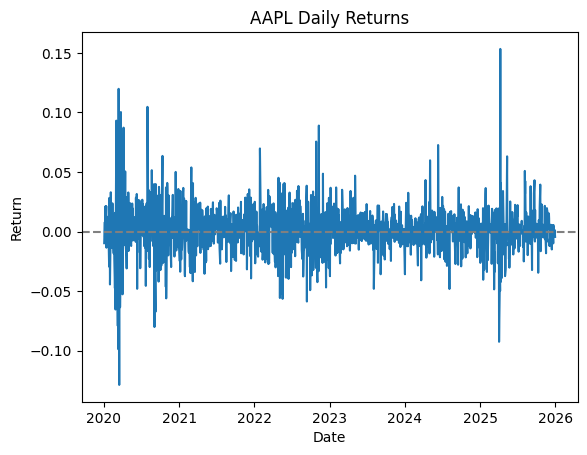

In [38]:
import matplotlib.pyplot as plt

plt.plot(data.index, data['Return'])
plt.axhline(0, color='gray', linestyle='--')
plt.title(f"{ticker} Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

In [39]:
import sqlite3

conn = sqlite3.connect('volatility_project.db')
data.to_sql(f'{ticker}_prices', conn, if_exists='replace', index=True)

1507

In [40]:
query = f"SELECT * FROM {ticker}_prices ORDER BY Date DESC LIMIT 5"
result = pd.read_sql(query, conn)
print(result)

                  Date       Close        High         Low        Open  \
0  2025-12-31 00:00:00  271.355835  273.172467  271.246054  272.553622   
1  2025-12-30 00:00:00  272.573578  273.571723  271.775074  272.304090   
2  2025-12-29 00:00:00  273.252350  273.851213  271.844961  272.184327   
3  2025-12-26 00:00:00  272.892975  274.859323  272.353968  273.651575   
4  2025-12-24 00:00:00  273.302216  274.919206  271.695216  271.834940   

     Volume    Return  
0  27293600 -0.004468  
1  22139600 -0.002484  
2  23715200  0.001317  
3  21521800 -0.001497  
4  17910600  0.005324  


In [41]:
from statsmodels.tsa.stattools import adfuller
result_price = adfuller(data['Close'])#the standard stationarity test
print("ADF Statistic:", result_price[0])
print("p-value:", result_price[1])

ADF Statistic: -0.9333691540124028
p-value: 0.776784990800196


In [42]:
result_return = adfuller(data['Return'])
print("ADF Statistic:", result_return[0])
print("p-value:", result_return[1])

ADF Statistic: -13.098682375891002
p-value: 1.7279085844799798e-24


In [43]:
data['RollingVol'] = data['Return'].rolling(window=20).std()#calculates the standard deviation of every 20 day window
data[['Return', 'RollingVol']]

Price,Return,RollingVol
Date,,
2020-01-03,-0.009722,NaN
2020-01-06,0.007968,NaN
2020-01-07,-0.004703,NaN
2020-01-08,0.016086,NaN
2020-01-09,0.021241,NaN
...,...,...
2025-12-24,0.005324,0.007907
2025-12-26,-0.001497,0.007884
2025-12-29,0.001317,0.007798


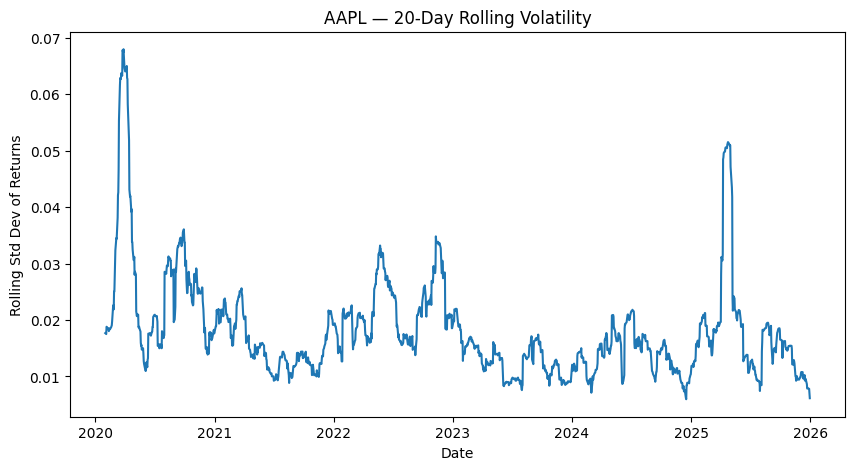

In [44]:
plt.figure(figsize=(10, 5))
plt.plot(data.index, data['RollingVol'])
plt.title(f"{ticker} — 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Std Dev of Returns")
plt.show()

In [45]:
data.to_sql(f'{ticker}_prices', conn, if_exists='replace', index=True)
query = f"SELECT Date, Close, Return, RollingVol FROM {ticker}_prices ORDER BY Date DESC"
result = pd.read_sql(query, conn)
print(result)

                     Date       Close    Return  RollingVol
0     2025-12-31 00:00:00  271.355835 -0.004468    0.006140
1     2025-12-30 00:00:00  272.573578 -0.002484    0.006813
2     2025-12-29 00:00:00  273.252350  0.001317    0.007798
3     2025-12-26 00:00:00  272.892975 -0.001497    0.007884
4     2025-12-24 00:00:00  273.302216  0.005324    0.007907
...                   ...         ...       ...         ...
1502  2020-01-09 00:00:00   74.568802  0.021241         NaN
1503  2020-01-08 00:00:00   73.017838  0.016086         NaN
1504  2020-01-07 00:00:00   71.861855 -0.004703         NaN
1505  2020-01-06 00:00:00   72.201408  0.007968         NaN
1506  2020-01-03 00:00:00   71.630646 -0.009722         NaN

[1507 rows x 4 columns]


In [46]:
from arch import arch_model

# GARCH typically wants returns scaled as percentages, not decimals
returns_pct = data['Return'] * 100

model = arch_model(returns_pct, vol='Garch', p=1, q=1)#p=shock terms and q=past variance terms
fitted = model.fit()
print(fitted.params)
print(fitted.pvalues)
print(fitted.conf_int())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 8999.252767244085
Iteration:      2,   Func. Count:     16,   Neg. LLF: 563568.2987462563
Iteration:      3,   Func. Count:     24,   Neg. LLF: 3492.589512233145
Iteration:      4,   Func. Count:     31,   Neg. LLF: 3368.0872013188364
Iteration:      5,   Func. Count:     38,   Neg. LLF: 3006.8063776729527
Iteration:      6,   Func. Count:     43,   Neg. LLF: 3006.756242532843
Iteration:      7,   Func. Count:     48,   Neg. LLF: 3006.7547392889037
Iteration:      8,   Func. Count:     53,   Neg. LLF: 3006.754729738474
Iteration:      9,   Func. Count:     57,   Neg. LLF: 3006.7547297401075
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3006.754729738474
            Iterations: 9
            Function evaluations: 57
            Gradient evaluations: 9
mu          0.150964
omega       0.136168
alpha[1]    0.102229
beta[1]     0.862514
Name: params, dtype: float64
mu           8.814122e-04
om

In [47]:
sigma^2=omega+alpha*(shock_t-1)^2+beta*(sigma_t-1)^2+omega
beta=0.86,86% of yesterday's volatility persists into today
alpha=0.1022,10% of yesterdays shock squared feeds in tdys variance
omega=0.1362,how much variance exists even with zero persistence and zero shocks

alpha + beta = 0.1022 + 0.8625 = 0.9647, overall volatility persistance
how long a volatility spike takes to fade back to normal. A value close to 1.0 means shocks decay very slowly (long memory)
At 0.9647, this is a high but stable value-— high enough to confirm real, strong volatility clustering


SyntaxError: unterminated string literal (detected at line 2) (2759280749.py, line 2)

In [ ]:
data['GARCH_Vol'] = fitted.conditional_volatility/100
data[['RollingVol', 'GARCH_Vol']].tail(10)

Price,RollingVol,GARCH_Vol
Date,,
2025-12-17,0.009612,0.012449
2025-12-18,0.009581,0.012690
2025-12-19,0.009374,0.012350
2025-12-22,0.008644,0.012114
2025-12-23,0.007854,0.012386
2025-12-24,0.007907,0.012136
2025-12-26,0.007884,0.011922
2025-12-29,0.007798,0.011710
2025-12-30,0.006813,0.011485


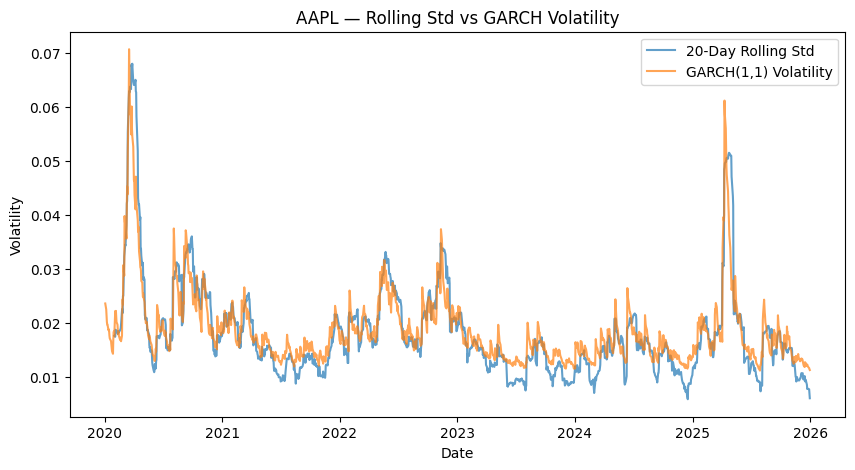

In [ ]:
data['GARCH_Vol_scaled'] = fitted.conditional_volatility / 100

plt.figure(figsize=(10, 5))
plt.plot(data.index, data['RollingVol'], label='20-Day Rolling Std', alpha=0.7)
plt.plot(data.index, data['GARCH_Vol_scaled'], label='GARCH(1,1) Volatility', alpha=0.7)
plt.title(f"{ticker} — Rolling Std vs GARCH Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()

In [49]:
split_point = int(len(data) * 0.9)
#90/10 split means the model trains on the first ~90% of days and gets tested on the last ~10%
train = data.iloc[:split_point]
test = data.iloc[split_point:]

print(f"Train: {train.index[0]} to {train.index[-1]} ({len(train)} days)")
print(f"Test: {test.index[0]} to {test.index[-1]} ({len(test)} days)")

Train: 2020-01-03 00:00:00 to 2025-05-27 00:00:00 (1356 days)
Test: 2025-05-28 00:00:00 to 2025-12-31 00:00:00 (151 days)


In [50]:
train_returns = train['Return'] * 100

model_train = arch_model(train_returns, vol='Garch', p=1, q=1)
fitted_train = model_train.fit(disp='off')
print(fitted_train.params)

mu          0.141841
omega       0.133472
alpha[1]    0.096080
beta[1]     0.872009
Name: params, dtype: float64


In [51]:
import numpy as np
n_test = len(test)
forecast = fitted_train.forecast(horizon=n_test)
#horizon=n_test tells it: "forecast this many steps ahead"
forecast_variance = forecast.variance.values[-1, :]#he forecast object stores results per origin-date; [-1, :] grabs the most recent (last) forecast origin's full horizon
forecast_vol = np.sqrt(forecast_variance) / 100  # back to original (non-percent) scale
print(len(forecast_vol))
print(len(test))

151
151


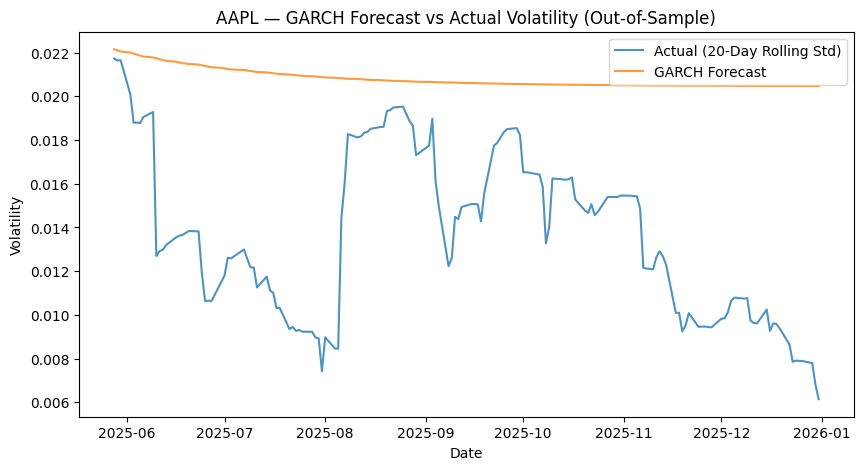

In [52]:
test = test.copy()
test['GARCH_Forecast'] = forecast_vol

plt.figure(figsize=(10, 5))
plt.plot(test.index, test['RollingVol'], label='Actual (20-Day Rolling Std)', alpha=0.8)
plt.plot(test.index, test['GARCH_Forecast'], label='GARCH Forecast', alpha=0.8)
plt.title(f"{ticker} — GARCH Forecast vs Actual Volatility (Out-of-Sample)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()

In [53]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(test['RollingVol'], test['GARCH_Forecast']))
print(f"RMSE: {rmse:.5f}")

naive_forecast = np.full(len(test), train['RollingVol'].mean())
rmse_naive = np.sqrt(mean_squared_error(test['RollingVol'], naive_forecast))
print(f"Naive (constant mean) RMSE: {rmse_naive:.5f}")#"on average, the forecast was off by about 0.005,"

RMSE: 0.00801
Naive (constant mean) RMSE: 0.00617


In [57]:
full_returns = data['Return'] * 100
model_full = arch_model(full_returns, vol='Garch', p=1, q=1)
rolling_forecasts = model_full.forecast(params=fitted_train.params, start=split_point, horizon=1)
forecast_variance_1day = rolling_forecasts.variance['h.1']
forecast_vol_1day = np.sqrt(forecast_variance_1day) / 100

print(len(forecast_vol_1day))

151


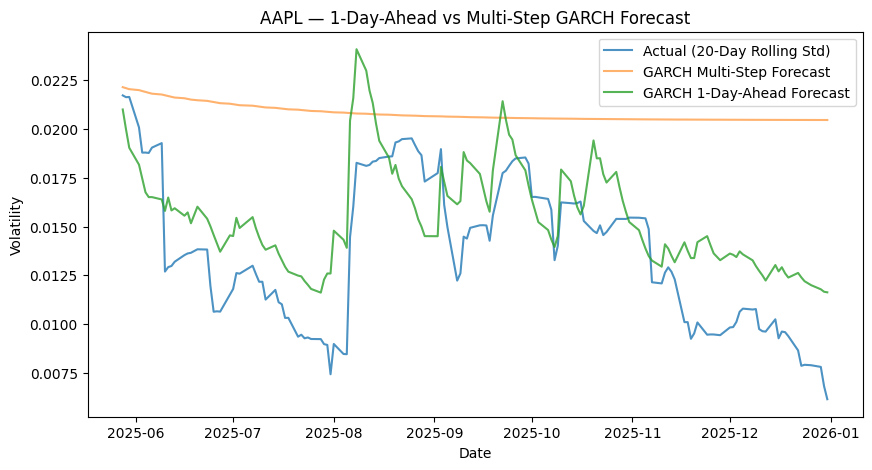

In [58]:
test['GARCH_1day_Forecast'] = forecast_vol_1day.values

plt.figure(figsize=(10, 5))
plt.plot(test.index, test['RollingVol'], label='Actual (20-Day Rolling Std)', alpha=0.8)
plt.plot(test.index, test['GARCH_Forecast'], label='GARCH Multi-Step Forecast', alpha=0.6)
plt.plot(test.index, test['GARCH_1day_Forecast'], label='GARCH 1-Day-Ahead Forecast', alpha=0.8)
plt.title(f"{ticker} — 1-Day-Ahead vs Multi-Step GARCH Forecast")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()

In [ ]:
rmse_1day = np.sqrt(mean_squared_error(test['RollingVol'], test['GARCH_1day_Forecast']))
print(f"1-Day-Ahead GARCH RMSE: {rmse_1day:.5f}")
print(f"Multi-Step GARCH RMSE:  {rmse:.5f}")
print(f"Naive (constant mean) RMSE: {rmse_naive:.5f}")
#GARCH's real strength is reacting to yesterday's actual shock

1-Day-Ahead GARCH RMSE: 0.00295
Multi-Step GARCH RMSE:  0.00801
Naive (constant mean) RMSE: 0.00617


In [ ]:
import statsmodels.api as sm

data['Return_lag1'] = data['Return'].shift(1)#.shift(1) — moves every value down by one row,
data[['Return', 'Return_lag1']].head()

Price,Return,Return_lag1
Date,,
2020-01-03,-0.009722,NaN
2020-01-06,0.007968,-0.009722
2020-01-07,-0.004703,0.007968
2020-01-08,0.016086,-0.004703
2020-01-09,0.021241,0.016086


In [61]:
reg_data = data[['Return', 'Return_lag1']].dropna()

y = reg_data['Return']
X = reg_data['Return_lag1']
X = sm.add_constant(X)#OLS needs an explicit intercept term

ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Return   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     11.35
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           0.000773
Time:                        17:34:10   Log-Likelihood:                 3757.5
No. Observations:                1506   AIC:                            -7511.
Df Residuals:                    1504   BIC:                            -7500.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0012      0.001      2.286      

In [ ]:
#apply newey west because of serial correlation
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
#results show no serial correlation through breusch godfrey
bg_test = acorr_breusch_godfrey(ols_model, nlags=5)
print(f"LM Statistic: {bg_test[0]:.4f}, p-value: {bg_test[1]:.4f}")

LM Statistic: 5.2393, p-value: 0.3874


In [63]:
ols_nw = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
print(ols_nw.summary())

                            OLS Regression Results                            
Dep. Variable:                 Return   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     2.421
Date:                Tue, 28 Jul 2026   Prob (F-statistic):              0.120
Time:                        17:39:25   Log-Likelihood:                 3757.5
No. Observations:                1506   AIC:                            -7511.
Df Residuals:                    1504   BIC:                            -7500.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0012      0.001      2.315      

In [ ]:
#A simple OLS regression of today's return on yesterday's return finds a statistically significant negative coefficient (-0.0865, p=0.001) under standard errors,
#  suggesting mild mean-reversion. However, Newey-West (HAC) standard errors — justified by the same volatility clustering documented via GARCH in this project — inflate the standard error substantially (0.026 → 0.056),
#  rendering the effect statistically insignificant (p=0.120) once heteroskedasticity is properly accounted for.
#  This illustrates a core lesson from applied econometrics: apparent predictability in financial returns can be an artifact of uncorrected, time-varying variance rather than genuine structure.